<a href="https://colab.research.google.com/github/sayyidul/mental_health_prediction/blob/main/1_MentalHealthPrediction_EDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# MENGHUBUNGKAN GOOGLE DRIVE DATASET
# ==========================================================
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/03 Dataset/data.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Mental Health (EDA + Prediction)**

In [ ]:
#import important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing
from sklearn import metrics
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import warnings
warnings.filterwarnings("ignore")

# 2- Call Datasets

In [ ]:
Data1 = pd.read_csv('/content/drive/MyDrive/03 Dataset/data.csv')

In [ ]:
df1 = pd.DataFrame(Data1)

# 3- Functional Describe of All Datasets

In [ ]:
def describe(df):

  variables = []
  dtypes = []
  count = []
  unique = []
  missing = []

  for item in df.columns:
    variables.append(item)
    dtypes.append(df[item].dtype)
    count.append(df[item].count())
    unique.append(df[item].nunique())
    missing.append(df[item].isnull().sum())

  output = pd.DataFrame({
      'variable' : variables,
      'dtype' : dtypes,
      'count' : count,
      'unique' : unique,
      'missing value' : missing
  })

  return output

In [ ]:
class color:
  BLUE = '\033[94m'
  UNDERLINE = '\033[4m'
  END = '\033[0m'
  BOLD = '\033[1m'

# 4- Output of Describes

In [ ]:
print(color.BOLD + color.BLUE + color.UNDERLINE + '"The Describe table of df1 : Mental Health Depression"' + color.END)
print(describe(df1))

"The Describe table of df1 : Mental Health Depression"
           variable    dtype  count  unique  missing value
0         inter_dom   object    268       2             18
1            Region   object    268       5             18
2            Gender   object    268       2             18
3          Academic   object    268       2             18
4               Age  float64    268      14             18
5          Age_cate  float64    268       5             18
6              Stay  float64    268       9             18
7         Stay_Cate   object    268       3             18
8          Japanese  float64    268       5             18
9     Japanese_cate   object    268       3             18
10          English  float64    268       5             18
11     English_cate   object    268       3             18
12         Intimate   object    260       2             26
13         Religion   object    268       2             18
14          Suicide   object    268       2             18
1

In [ ]:
# # Update plotly ke versi terbaru
# !pip install --upgrade plotly

# import plotly.express as px
# import plotly.io as pio

# # Set renderer default
# pio.renderers.default = 'colab'  # atau 'colab' jika di Google Colab

# 5- Some Visualizations with Plotly

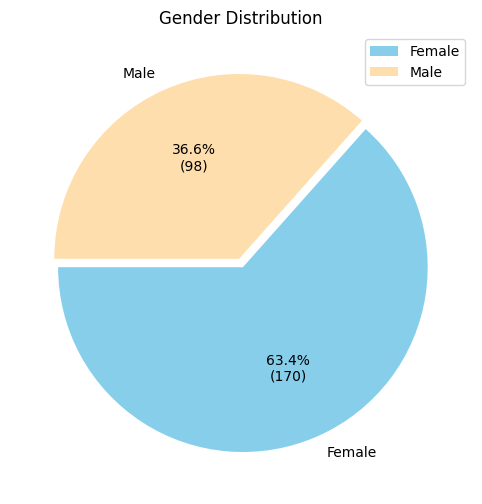

In [ ]:
plt.figure(figsize=(12,6))
plt.title("Gender Distribution")

gender_counts = df1.Gender.value_counts()

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return my_format

plt.pie(gender_counts,
        explode=(0.025, 0.025),
        labels=gender_counts.index,
        colors=['skyblue','navajowhite'],
        autopct=autopct_format(gender_counts),
        startangle=180)

plt.legend()
plt.show()


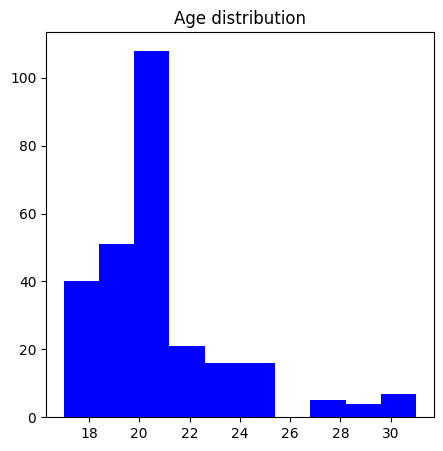

In [ ]:
plt.figure(figsize=(5,5))
plt.hist(df1['Age'],color='b')
plt.title("Age distribution");

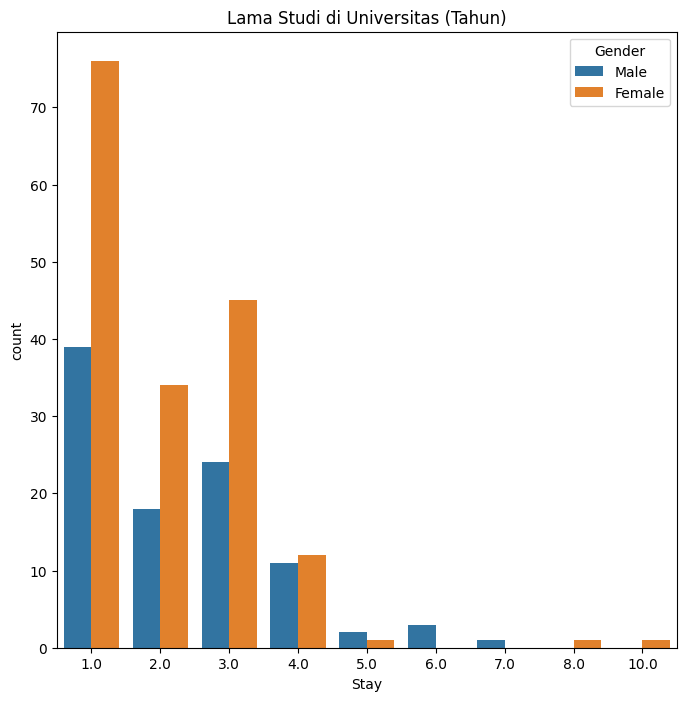

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(data=df1, x='Stay', hue='Gender')
plt.title("Lama Studi di Universitas (Tahun)");

In [ ]:
# ========================================================================
# STEP : DATA CLEANING & LABEL ENCODING
# ========================================================================
# Standardize labels in Academic
df1['Academic'] = df1['Academic'].replace({'Grad': 'Graduate', 'Under': 'Undergraduate'})

# Encode Depression labels: Yes = 1, No = 0
df1['Dep'] = df1['Dep'].map({'Yes': 1, 'No': 0})

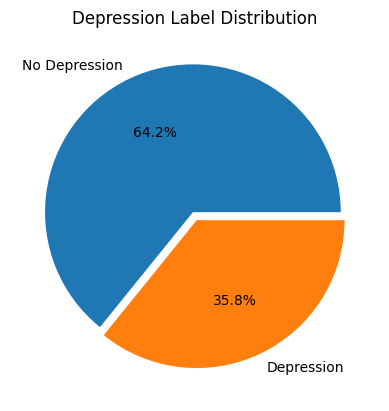

In [ ]:
# ========================================================================
# STEP : VISUALIZATIONS
# ========================================================================

# 1. Depression Label Distribution
dep_counts = df1['Dep'].value_counts()
plt.title("Depression Label Distribution")
plt.pie(dep_counts, labels=["No Depression", "Depression"],
        autopct='%1.1f%%', explode=[0.03, 0.03])
plt.show()

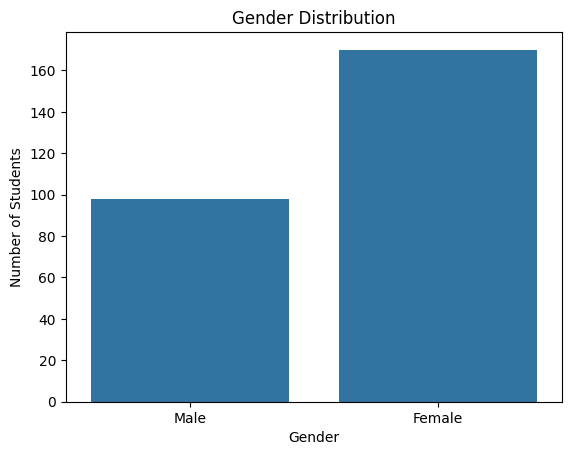

In [ ]:
# 2. Gender Distribution
sns.countplot(data=df1, x='Gender')
plt.title("Gender Distribution")
plt.ylabel("Number of Students")
plt.show()

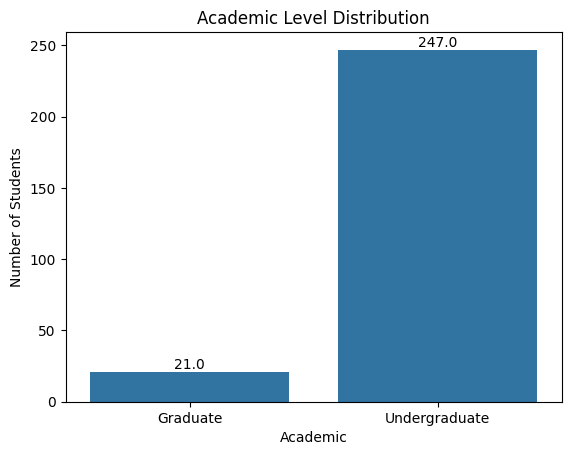

In [ ]:
# 3. Academic Level Distribution
ax = sns.countplot(data=df1, x='Academic')
plt.title("Academic Level Distribution")
plt.ylabel("Number of Students")

# Tambahkan label jumlah pada tiap bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
plt.show()


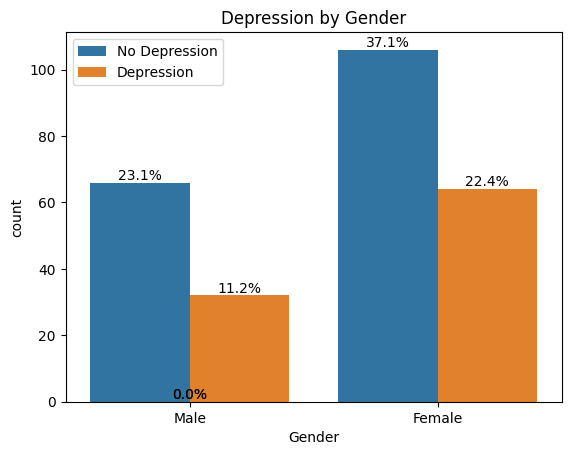

In [ ]:
# ========================================================================
# STEP : FEATURE RELATIONSHIPS WITH DEPRESSION
# ========================================================================

# Depression vs Gender
ax = sns.countplot(data=df1, x='Gender', hue='Dep')
plt.title("Depression by Gender")
plt.legend(["No Depression", "Depression"])

# Hitung persentase
total = len(df1)  # total seluruh data
for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.show()

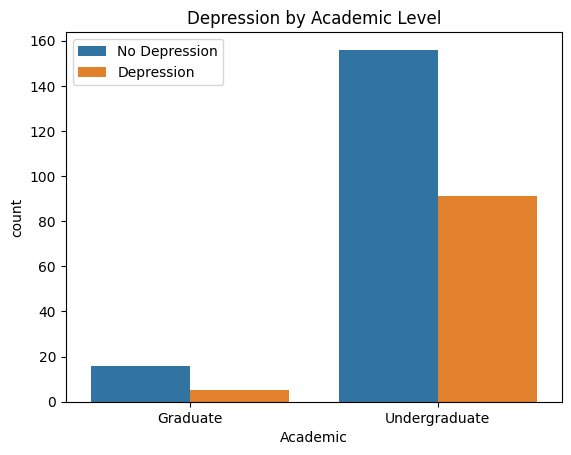

In [ ]:
# Depression vs Academic Level
sns.countplot(data=df1, x='Academic', hue='Dep')
plt.title("Depression by Academic Level")
plt.legend(["No Depression", "Depression"])
plt.show()

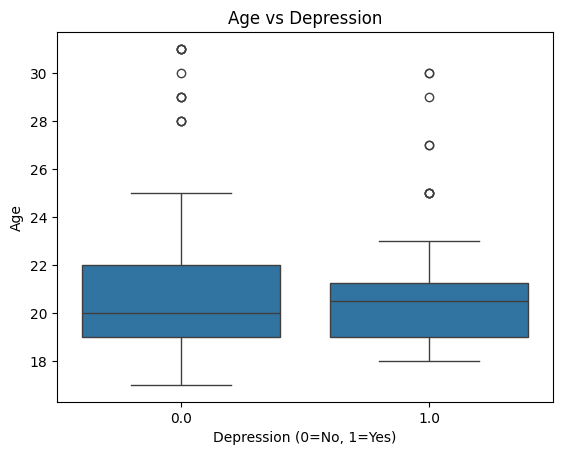

In [ ]:
# Age Distribution vs Depression
sns.boxplot(data=df1, x='Dep', y='Age')
plt.title("Age vs Depression")
plt.xlabel("Depression (0=No, 1=Yes)")
plt.show()

**Interpretasi Boxplot: Age vs Depression**

Visualisasi ini membandingkan distribusi usia pada dua kelompok mahasiswa:
0 = Tidak Depresi
1 = Depresi

Temuan Utama:
1. Median usia kedua kelompok hampir sama (sekitar 20–21 tahun),
   sehingga usia bukan faktor pembeda yang kuat terhadap kondisi depresi.

2. Kelompok tanpa depresi memiliki rentang usia yang lebih lebar
   (sekitar 17–25 tahun), sementara kelompok dengan depresi memiliki
   rentang yang lebih sempit (sekitar 18–23 tahun).

3. Terdapat outlier pada kedua kelompok: pada kelompok “Tidak Depresi”,
   outlier mencapai usia 28–31 tahun, sedangkan pada kelompok “Depresi”,
   outlier tersebar di usia 25–30 tahun. Hal ini menunjukkan adanya
   mahasiswa yang usianya lebih tua dari rata-rata mahasiswa lain
   (misal mahasiswa pindahan, pekerja yang kuliah lagi, atau program lanjutan)
   di kedua kelompok.

**Kesimpulan:**
Usia tidak menunjukkan perbedaan distribusi yang signifikan antara
mahasiswa yang mengalami depresi dan tidak mengalami depresi. Dengan demikian,
usia bukan prediktor utama dalam membedakan kondisi depresi pada dataset ini.

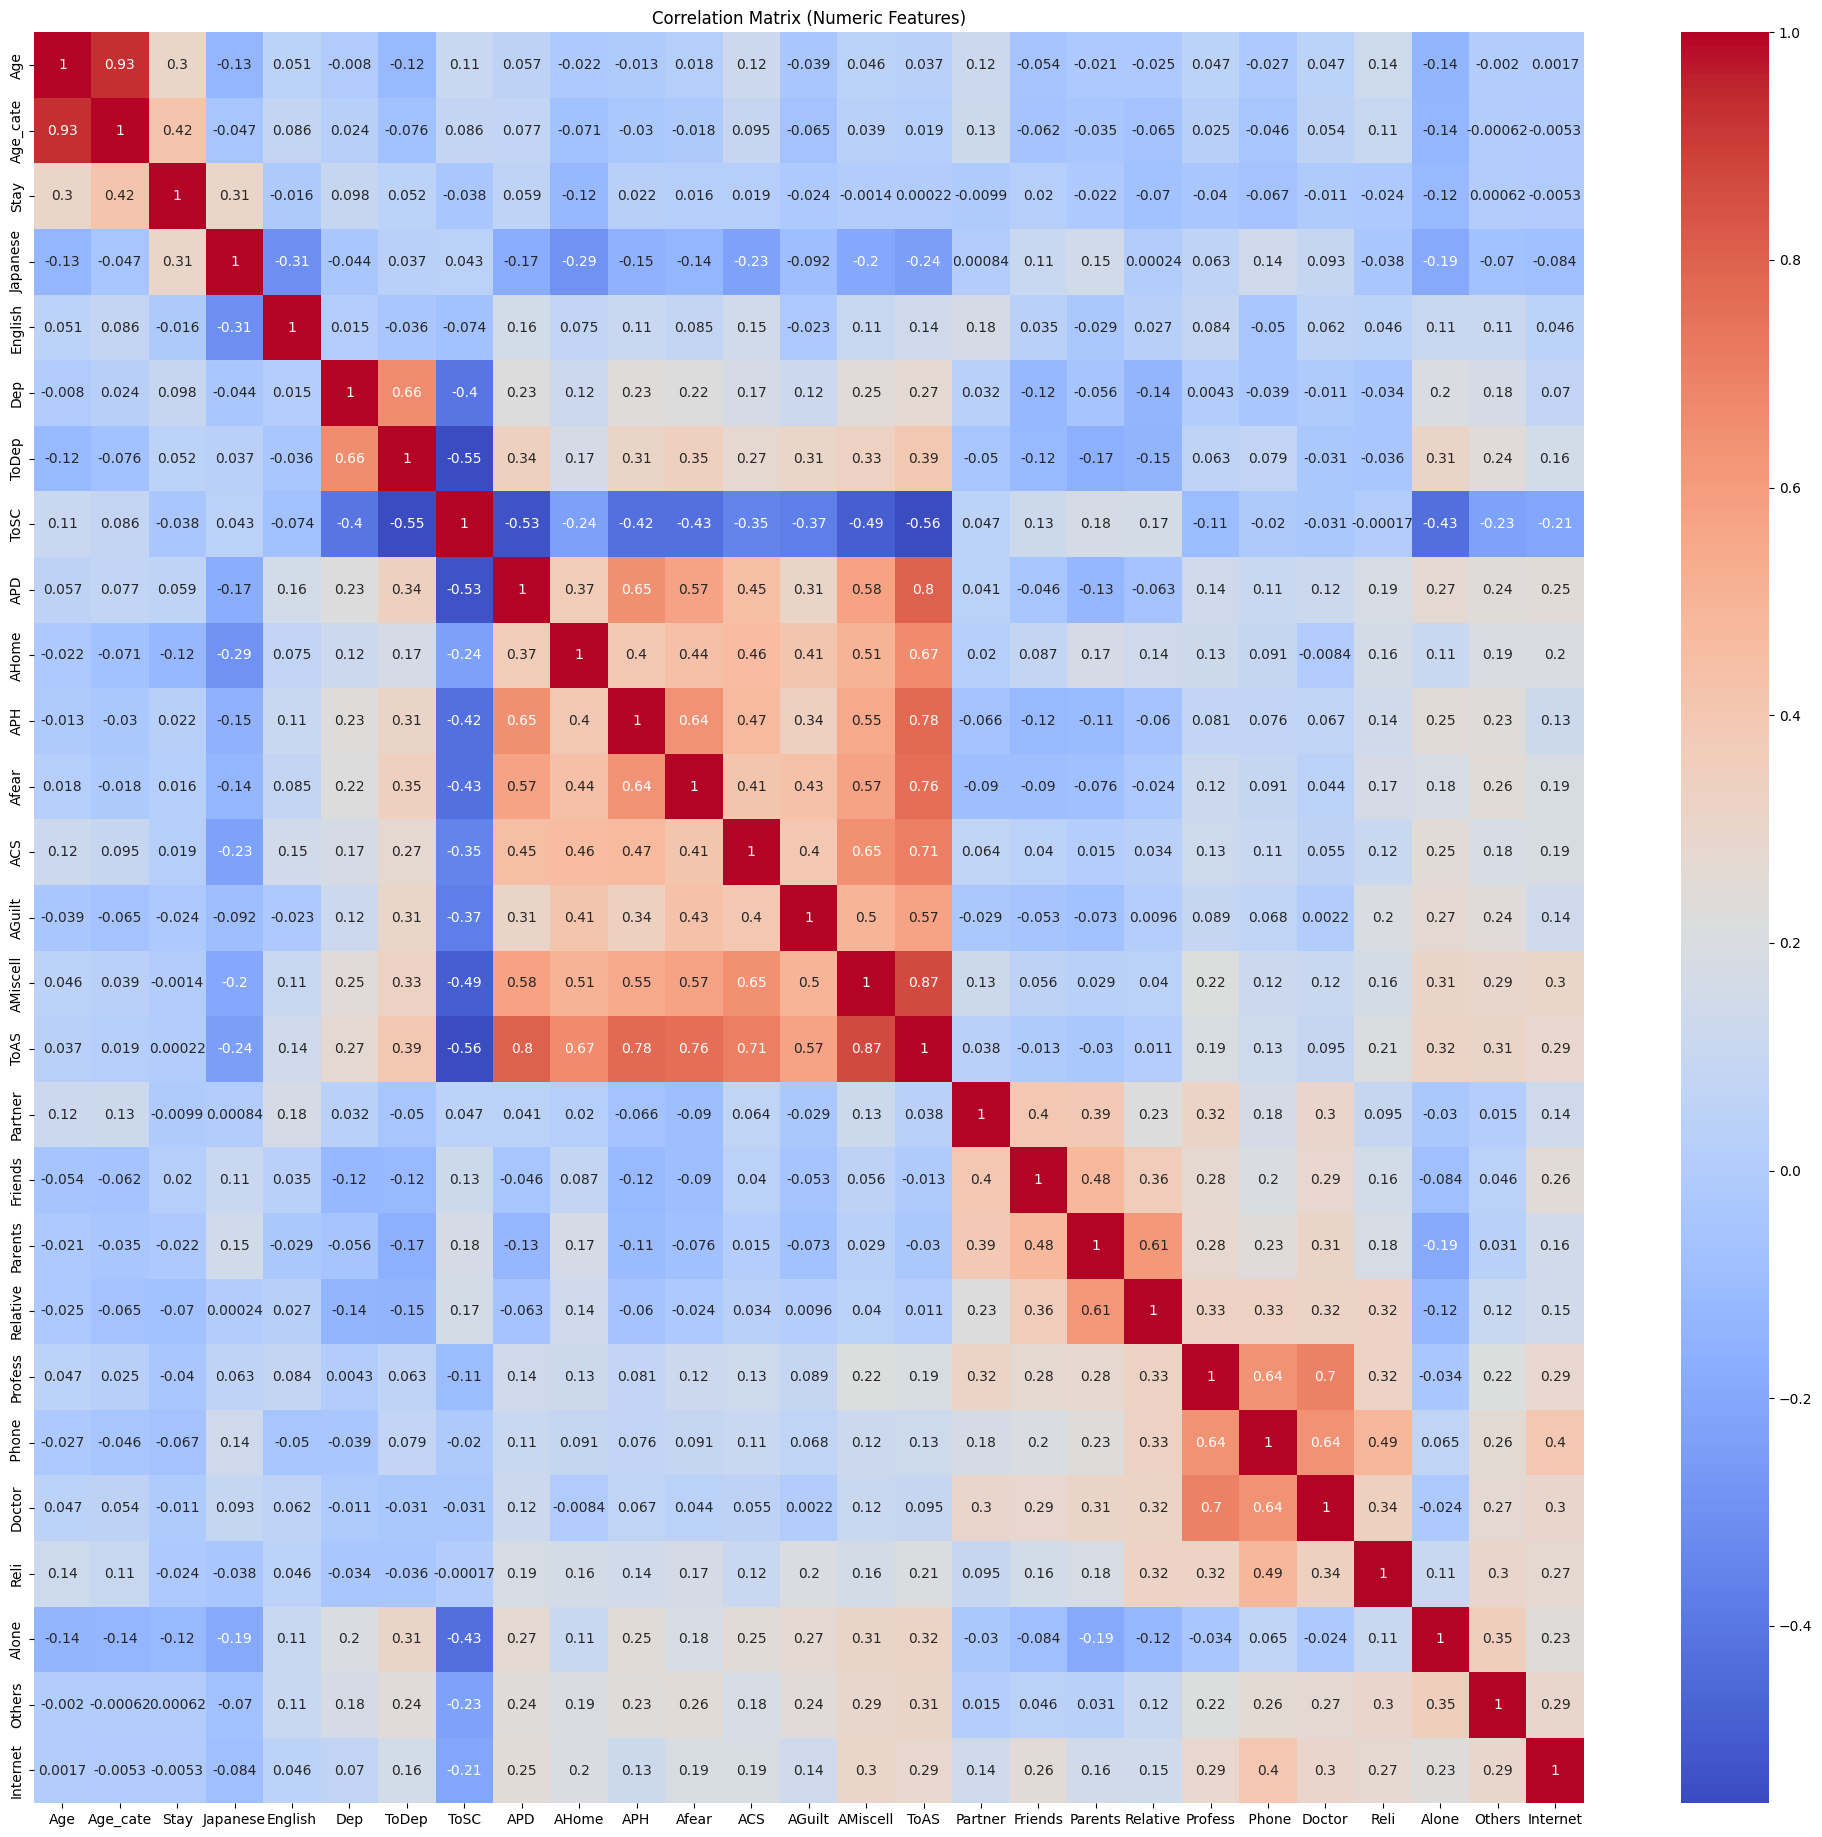

In [ ]:
# ========================================================================
# STEP : CORRELATION ANALYSIS
# ========================================================================
numeric_cols = df1.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(25,23))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

# 🧠 Interpretasi Heatmap Korelasi (Disesuaikan dengan Dataset Terbaru)

Heatmap ini menggambarkan hubungan linear antar variabel numerik menggunakan **koefisien Pearson Correlation**.  
Nilai korelasi berkisar antara **–1 hingga +1**, di mana:

- **+1** → korelasi positif sempurna *(kedua variabel meningkat bersama)*  
- **0** → tidak ada hubungan linear  
- **–1** → korelasi negatif sempurna *(saling berlawanan arah)*  

Warna **merah** menandakan hubungan positif, sedangkan **biru** menunjukkan hubungan negatif.

---

## 📘 1. Hubungan antar Faktor Sosial dan Dukungan Emosional

- **Parents–Relative (r = 0.61)** dan **Parents–Friends (r = 0.48)**  
  → Mahasiswa yang memiliki hubungan baik dengan orang tua cenderung juga memiliki relasi yang sehat dengan kerabat dan teman.  
  Hal ini memperkuat konsep bahwa **dukungan sosial bersifat terintegrasi dan saling menguatkan**.

- **Profess–Doctor (r = 0.70)**  
  → Mahasiswa yang aktif mencari bantuan profesional juga cenderung **berinteraksi atau mendapatkan dukungan dari tenaga medis (dokter)**.  
  Ini menunjukkan pola konsistensi dalam **pencarian bantuan formal** terkait kesehatan mental.

---

## 💬 2. Faktor Religiusitas (Reli)

- **Reli–Doctor (r = 0.34)** dan **Reli–Profess (r = 0.32)**  
  → Korelasi positif moderat ini menunjukkan bahwa mahasiswa dengan tingkat **religiusitas lebih tinggi** juga cenderung **terbuka terhadap bantuan profesional atau medis**.  
  Artinya, **keimanan dan pencarian bantuan profesional tidak saling meniadakan**, melainkan **saling melengkapi sebagai mekanisme coping**.

---

## 🧍 3. Perasaan Kesepian (Alone)

- **Alone–ToSC (r = –0.43)** dan **Alone–Dep (r = 0.20)**  
  → Semakin sering seseorang merasa sendiri, semakin kecil kecenderungannya untuk mencari konseling (korelasi negatif moderat).  
  Namun hubungan Alone dengan tingkat depresi (Dep) pada dataset ini tergolong **lemah (r = 0.20)**, sehingga kesepian tampaknya lebih berkaitan dengan **rendahnya kecenderungan mencari bantuan**, dibanding secara langsung memprediksi status depresi.

---

## 💡 4. Kecenderungan Mencari Bantuan (ToSC)

- **ToSC–ToDep (r = –0.55)** dan **ToSC–Dep (r = –0.40)**  
  → Semakin tinggi kecenderungan mahasiswa untuk mencari konseling, semakin rendah kecenderungan dan tingkat depresi mereka.  
  Ini menjadi **faktor protektif utama** dalam penelitian ini.

---

## 🌐 5. Faktor Internet

- **Internet–ToDep (r = 0.16)** dan **Internet–Dep (r = 0.07)**  
  → Keduanya tergolong **korelasi sangat lemah hingga dapat diabaikan**.  
  Artinya, pada dataset ini **penggunaan internet tidak tampak sebagai faktor risiko yang menonjol**, baik terhadap kecenderungan maupun tingkat depresi mahasiswa — berbeda dari asumsi awal bahwa internet berkorelasi kuat dengan risiko depresi.

---

## 👥 6. Faktor Partner

- **Partner–Friends (r = 0.40)** dan **Partner–Parents (r = 0.39)**  
  → Mahasiswa yang memiliki pasangan juga cenderung memiliki **jejaring sosial yang lebih kuat**.  
  Ini sejalan dengan teori **social buffering**, di mana hubungan interpersonal yang dekat dapat **menurunkan tekanan psikologis**.

---

## 📈 7. Kesimpulan Akademik

Analisis korelasi menunjukkan bahwa **faktor sosial dan interpersonal** seperti:
- Dukungan dari orang tua, teman, dan kerabat  
- Hubungan dengan pasangan  
memiliki hubungan positif dan membentuk **jaringan dukungan yang penting bagi kesejahteraan mental mahasiswa**.

**ToSC (tendency to seek counseling)** menunjukkan korelasi negatif yang kuat terhadap depresi, menandakan bahwa **perilaku proaktif mencari bantuan merupakan faktor protektif** yang perlu diperkuat melalui program kampus atau layanan konseling mahasiswa.

**Perasaan kesepian (Alone)** tetap berkorelasi positif dengan depresi, namun kekuatannya **lemah** pada dataset ini, sehingga sebaiknya dipandang sebagai salah satu dari beberapa faktor kontribusi, bukan determinan tunggal. Sebaliknya, **faktor penggunaan internet tidak menunjukkan hubungan yang berarti** dengan depresi maupun kecenderungan depresi pada dataset ini.

---

📊 **Kesimpulan Umum:**  
Heatmap ini menegaskan bahwa **interaksi sosial, religiusitas, dan perilaku mencari bantuan profesional** berperan penting dalam membentuk **kondisi kesehatan mental mahasiswa**, sementara **faktor kesepian berkontribusi secara lebih moderat/lemah** dan **penggunaan internet tidak menunjukkan hubungan yang signifikan** terhadap depresi pada dataset ini.
